# 🏦 Detección de Fraude — Transacciones Bancarias
## Proyecto de Machine Learning | Python · scikit-learn · matplotlib

**Objetivo:** Detectar transacciones fraudulentas con tarjetas de crédito usando modelos de clasificación.

| Dato | Valor |
|---|---|
| Registros | 50,000 transacciones |
| Tasa de fraude | ~1.5 % |
| Modelos | Logistic Regression · Random Forest · Gradient Boosting |


## 0. Setup

In [1]:
%matplotlib inline
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
os.makedirs("reports/figures", exist_ok=True)
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 1. Configuración de estilo

In [2]:
COLORS = {
    "bg": "#0D1117", "panel": "#161B22", "accent": "#00D4AA",
    "red": "#FF4B6E", "blue": "#4B9FFF", "yellow": "#FFD166",
    "text": "#E6EDF3", "muted": "#8B949E",
}
plt.rcParams.update({
    "figure.facecolor": COLORS["bg"],   "axes.facecolor":  COLORS["panel"],
    "axes.edgecolor":   COLORS["muted"],"axes.labelcolor": COLORS["text"],
    "xtick.color":      COLORS["muted"],"ytick.color":     COLORS["muted"],
    "text.color":       COLORS["text"], "grid.color":      "#21262D",
    "grid.linestyle":   "--", "font.family": "DejaVu Sans",
})
print("✅ Paleta de colores configurada")

✅ Paleta de colores configurada


## 2. Generación de datos sintéticos

In [3]:
def _hour_weights():
    w = np.ones(24); w[8:20] = 3.0; return w / w.sum()

def _fraud_hour_weights():
    w = np.ones(24); w[0:6] = 3.0; w[20:24] = 2.5; return w / w.sum()

def generate_banking_data(n_samples=50_000):
    fraud_ratio = 0.015
    n_fraud = int(n_samples * fraud_ratio)
    n_legit = n_samples - n_fraud

    legit = pd.DataFrame({
        "amount":            np.random.lognormal(3.5, 1.2, n_legit),
        "hour":              np.random.choice(range(24), n_legit, p=_hour_weights()),
        "day_of_week":       np.random.randint(0, 7, n_legit),
        "merchant_category": np.random.choice(["retail","food","travel","online","services"],
                                               n_legit, p=[0.35,0.30,0.10,0.15,0.10]),
        "distance_km":       np.random.exponential(20, n_legit),
        "n_transactions_1h": np.random.poisson(1.2, n_legit),
        "card_age_days":     np.random.randint(30, 3000, n_legit),
        "is_foreign":        np.random.binomial(1, 0.05, n_legit),
        "label": 0,
    })
    fraud = pd.DataFrame({
        "amount":            np.random.lognormal(5.2, 1.5, n_fraud),
        "hour":              np.random.choice(range(24), n_fraud, p=_fraud_hour_weights()),
        "day_of_week":       np.random.randint(0, 7, n_fraud),
        "merchant_category": np.random.choice(["retail","food","travel","online","services"],
                                               n_fraud, p=[0.10,0.05,0.20,0.50,0.15]),
        "distance_km":       np.random.exponential(150, n_fraud),
        "n_transactions_1h": np.random.poisson(4.5, n_fraud),
        "card_age_days":     np.random.randint(1, 300, n_fraud),
        "is_foreign":        np.random.binomial(1, 0.45, n_fraud),
        "label": 1,
    })
    df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

    # Feature engineering
    df["amount_log"]    = np.log1p(df["amount"])
    df["is_night"]      = df["hour"].apply(lambda h: int(h < 6 or h >= 22))
    df["is_weekend"]    = df["day_of_week"].apply(lambda d: int(d >= 5))
    df["high_velocity"] = (df["n_transactions_1h"] >= 3).astype(int)
    df["new_card"]      = (df["card_age_days"] < 30).astype(int)
    df["distance_log"]  = np.log1p(df["distance_km"])
    df["merchant_category"] = LabelEncoder().fit_transform(df["merchant_category"])
    return df

df = generate_banking_data(50_000)
print(f"✅ Dataset generado: {len(df):,} transacciones")
print(f"   Fraude: {df['label'].sum():,} ({df['label'].mean()*100:.2f}%)")
df.head()

✅ Dataset generado: 50,000 transacciones
   Fraude: 750 (1.50%)


,amount,hour,day_of_week,merchant_category,distance_km,n_transactions_1h,card_age_days,is_foreign,label,amount_log,is_night,is_weekend,high_velocity,new_card,distance_log
0,20.511837,14,5,4,44.398891,1,1723,0,0,3.068603,0,1,0,0,3.815488
1,15.880509,16,3,0,15.484267,1,185,0,0,2.826160,0,0,0,0,2.802406
2,8.401713,17,2,1,6.727313,3,1944,0,0,2.240892,0,0,1,0,2.044761
3,7.908558,19,2,0,35.221607,0,1228,1,0,2.187012,0,0,0,0,3.589656
4,144.057313,19,2,0,78.363813,1,1143,0,0,4.977129,0,0,0,0,4.374043


## 3. Análisis Exploratorio (EDA)

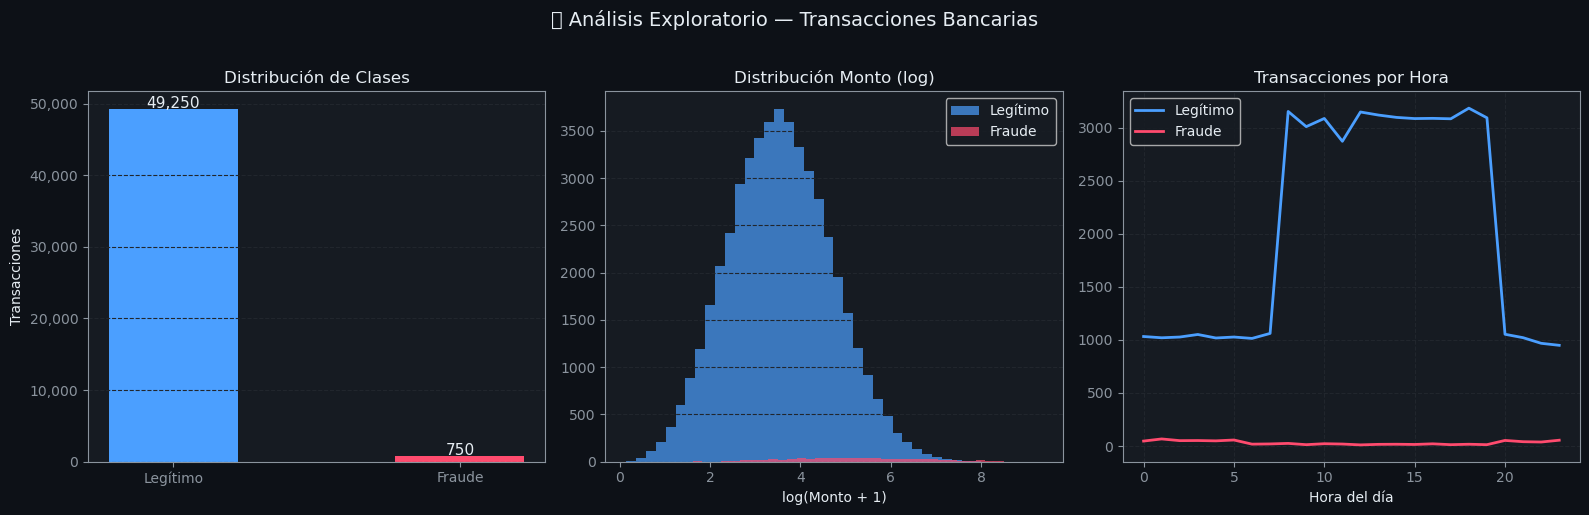

✅ Figura guardada


In [4]:
# Distribución de clases
counts = df["label"].value_counts()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Clases
bars = axes[0].bar(["Legítimo","Fraude"], counts.values,
                   color=[COLORS["blue"], COLORS["red"]], width=0.45, edgecolor="none")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f"{val:,}", ha="center", fontsize=11, color=COLORS["text"])
axes[0].set_title("Distribución de Clases"); axes[0].set_ylabel("Transacciones")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[0].grid(axis="y")

# Monto por clase
for label, col, lbl in [(0, COLORS["blue"], "Legítimo"), (1, COLORS["red"], "Fraude")]:
    axes[1].hist(np.log1p(df[df["label"]==label]["amount"]),
                 bins=40, alpha=0.7, color=col, label=lbl, edgecolor="none")
axes[1].set_title("Distribución Monto (log)"); axes[1].set_xlabel("log(Monto + 1)")
axes[1].legend(); axes[1].grid(axis="y")

# Transacciones por hora
for label, col, lbl in [(0, COLORS["blue"], "Legítimo"), (1, COLORS["red"], "Fraude")]:
    hour_counts = df[df["label"]==label].groupby("hour").size()
    axes[2].plot(hour_counts.index, hour_counts.values, color=col, label=lbl, lw=2)
axes[2].set_title("Transacciones por Hora"); axes[2].set_xlabel("Hora del día")
axes[2].legend(); axes[2].grid(True)

plt.suptitle("🏦 Análisis Exploratorio — Transacciones Bancarias", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/banking_class_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura guardada")

## 4. Preprocesamiento y Balanceo de clases

In [5]:
FEATURES = [
    "amount_log", "hour", "day_of_week", "merchant_category",
    "distance_log", "n_transactions_1h", "card_age_days",
    "is_foreign", "is_night", "is_weekend", "high_velocity", "new_card",
]

X = df[FEATURES]; y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

# Oversampling de clase minoritaria
df_tmp     = pd.concat([X_train, y_train], axis=1)
minority   = df_tmp[df_tmp["label"]==1]
majority   = df_tmp[df_tmp["label"]==0]
minority_up= resample(minority, replace=True, n_samples=len(majority)//3, random_state=SEED)
df_bal     = pd.concat([majority, minority_up])
X_res, y_res = df_bal.drop("label", axis=1), df_bal["label"]

print(f"Train original : {len(X_train):,} muestras | Fraude: {y_train.sum()}")
print(f"Train balanceado: {len(X_res):,} muestras  | Fraude: {y_res.sum()}")
print(f"Test           : {len(X_test):,} muestras  | Fraude: {y_test.sum()}")

Train original : 40,000 muestras | Fraude: 600
Train balanceado: 52,533 muestras  | Fraude: 13133
Test           : 10,000 muestras  | Fraude: 150


## 5. Entrenamiento de modelos

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", max_depth=8, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=SEED),
}

results = {}
for name, model in models.items():
    print(f"\n⏳ Entrenando {name}...")
    model.fit(X_res, y_res)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "roc_auc":  roc_auc_score(y_test, y_proba),
        "avg_prec": average_precision_score(y_test, y_proba),
        "f1":       f1_score(y_test, y_pred),
    }
    print(f"   ROC-AUC : {results[name]['roc_auc']:.4f}")
    print(f"   Avg Prec: {results[name]['avg_prec']:.4f}")
    print(f"   F1 Score: {results[name]['f1']:.4f}")

print("\n✅ Todos los modelos entrenados")


⏳ Entrenando Logistic Regression...
   ROC-AUC : 0.9991
   Avg Prec: 0.9595
   F1 Score: 0.6029

⏳ Entrenando Random Forest...
   ROC-AUC : 0.9989
   Avg Prec: 0.9456
   F1 Score: 0.7721

⏳ Entrenando Gradient Boosting...
   ROC-AUC : 0.9992
   Avg Prec: 0.9635
   F1 Score: 0.8852

✅ Todos los modelos entrenados


## 6. Evaluación — Reporte de Clasificación

In [7]:
best_name = max(results, key=lambda k: results[k]["roc_auc"])
print(f"🏆 Mejor modelo: {best_name} (ROC-AUC = {results[best_name]['roc_auc']:.4f})\n")
print("=" * 55)
for name, res in results.items():
    print(f"\n📊 {name}")
    print(classification_report(y_test, res["y_pred"],
                                 target_names=["Legítimo","Fraude"]))

🏆 Mejor modelo: Gradient Boosting (ROC-AUC = 0.9992)


📊 Logistic Regression
              precision    recall  f1-score   support

    Legítimo       1.00      0.98      0.99      9850
      Fraude       0.43      0.99      0.60       150

    accuracy                           0.98     10000
   macro avg       0.72      0.98      0.80     10000
weighted avg       0.99      0.98      0.98     10000


📊 Random Forest
              precision    recall  f1-score   support

    Legítimo       1.00      0.99      1.00      9850
      Fraude       0.65      0.96      0.77       150

    accuracy                           0.99     10000
   macro avg       0.82      0.98      0.88     10000
weighted avg       0.99      0.99      0.99     10000


📊 Gradient Boosting
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00      9850
      Fraude       0.87      0.90      0.89       150

    accuracy                           1.00     10000
   macro avg 

## 7. Visualizaciones — Curvas ROC

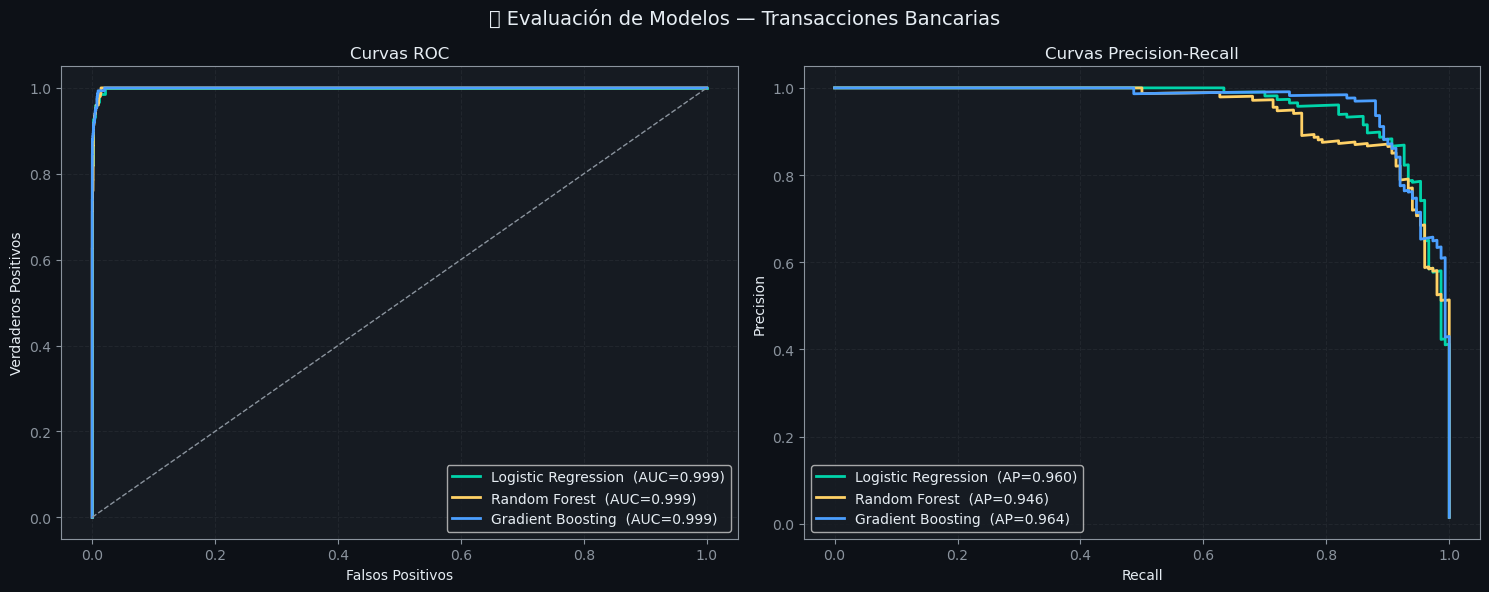

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = [COLORS["accent"], COLORS["yellow"], COLORS["blue"]]

# ROC
for (name, res), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name}  (AUC={res['roc_auc']:.3f})", color=col, lw=2)
axes[0].plot([0,1],[0,1],"--",color=COLORS["muted"],lw=1)
axes[0].set_title("Curvas ROC"); axes[0].set_xlabel("Falsos Positivos")
axes[0].set_ylabel("Verdaderos Positivos"); axes[0].legend(facecolor=COLORS["panel"])
axes[0].grid(True)

# Precision-Recall
for (name, res), col in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    axes[1].plot(rec, prec, label=f"{name}  (AP={res['avg_prec']:.3f})", color=col, lw=2)
axes[1].set_title("Curvas Precision-Recall"); axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision"); axes[1].legend(facecolor=COLORS["panel"])
axes[1].grid(True)

plt.suptitle("🏦 Evaluación de Modelos — Transacciones Bancarias", fontsize=14)
plt.tight_layout()
plt.savefig("reports/figures/banking_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Matriz de Confusión y Feature Importance

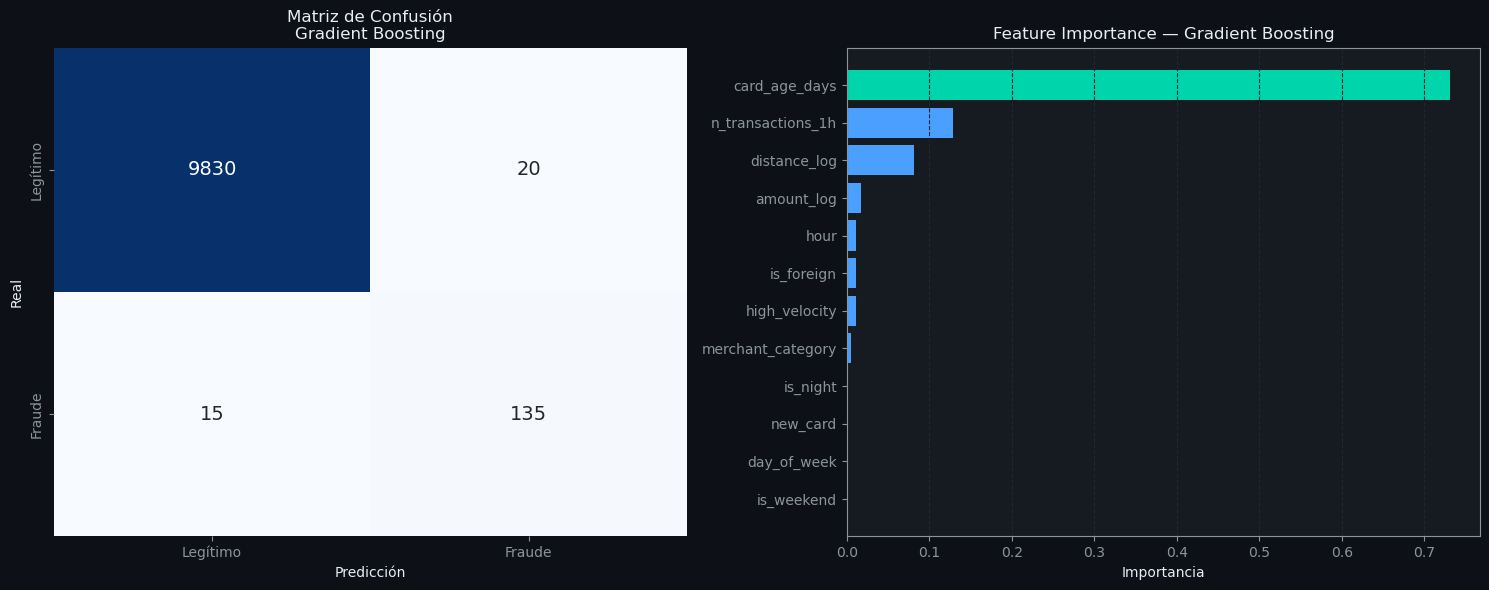

✅ Figuras guardadas en reports/figures/


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix — mejor modelo
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legítimo","Fraude"], yticklabels=["Legítimo","Fraude"],
            ax=axes[0], cbar=False, annot_kws={"size":14})
axes[0].set_title(f"Matriz de Confusión\n{best_name}")
axes[0].set_xlabel("Predicción"); axes[0].set_ylabel("Real")

# Feature Importance — Gradient Boosting
gb_model = results["Gradient Boosting"]["model"]
imp = pd.Series(gb_model.feature_importances_, index=FEATURES).sort_values()
colors_fi = [COLORS["accent"] if v == imp.max() else COLORS["blue"] for v in imp.values]
axes[1].barh(imp.index, imp.values, color=colors_fi, edgecolor="none")
axes[1].set_title("Feature Importance — Gradient Boosting")
axes[1].set_xlabel("Importancia"); axes[1].grid(axis="x")

plt.tight_layout()
plt.savefig("reports/figures/banking_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figuras guardadas en reports/figures/")

## 9. Resumen Final

In [10]:
summary = pd.DataFrame({
    "Modelo":    list(results.keys()),
    "ROC-AUC":   [f"{v['roc_auc']:.4f}"  for v in results.values()],
    "Avg Prec":  [f"{v['avg_prec']:.4f}" for v in results.values()],
    "F1-Score":  [f"{v['f1']:.4f}"       for v in results.values()],
})
print("🏆 RESULTADOS FINALES — Transacciones Bancarias")
print("=" * 55)
display(summary)
print(f"\n✅ Mejor modelo: {best_name} | ROC-AUC = {results[best_name]['roc_auc']:.4f}")

🏆 RESULTADOS FINALES — Transacciones Bancarias


,Modelo,ROC-AUC,Avg Prec,F1-Score
0,Logistic Regression,0.9991,0.9595,0.6029
1,Random Forest,0.9989,0.9456,0.7721
2,Gradient Boosting,0.9992,0.9635,0.8852



✅ Mejor modelo: Gradient Boosting | ROC-AUC = 0.9992
